In [1]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    _np,
    np,
    fft,
    interpolate,
    ndimage,
)
from prysm.coordinates import (
    make_xy_grid, 
    cart_to_polar,
)
from prysm.propagation import Wavefront as WF
from prysm.propagation import (
    focus_fixed_sampling,
    focus_fixed_sampling_backprop
)                              
from prysm.thinlens import (
    defocus_to_image_displacement,
    image_displacement_to_defocus,
)
from prysm.geometry import (
    offset_circle,
    circle,
    spider,
    gaussian,
)
from prysm.polynomials import (
    lstsq,
    noll_to_nm,
    zernike_nm,
    zernike_nm_seq,
    hopkins,
    sum_of_2d_modes,
    sum_of_2d_modes_backprop
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

from skimage.measure import centroid

import copy

from algos import FFPR2, PDPR, model, mean_squared_error, gain_invariant_error
import utils

from functools import partial

from lina.utils import TikhonovInverse

import config_um
import config_um_wcc
from Batoid4LOFT.LAZULI_STOP_mark11 import Lazuli_stop, readBulkMotion, readDeformation

from psd_utils import PSDUtils

from scipy.optimize import minimize

from scipy.interpolate import RegularGridInterpolator

from tqdm import tqdm

from psd_utils import PSDUtils

from model import telescope
# from algos import pdpr, OPD, ADPR
import utils

from functools import partial

from opt import F77LBFGSB, runN, RAdam
from IPython.display import clear_output

# logging stuff
import logging
psd_log = logging.getLogger('__psd_utils__')
psd_log.disabled = True

%reload_ext autoreload
%autoreload 2
%matplotlib inline

import toml

In [2]:
!nvidia-smi

Sun May  3 19:38:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:25:00.0 Off |                    0 |
| N/A   31C    P0             63W /  300W |    6026MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## SETUP MODEL

In [3]:
config = toml.load('/home/derbyk/src/ffpr/data/3m_off_axis_default.toml')
optic_opd_data = utils.load_pickle('/home/derbyk/src/ffpr/data/opd_maps.pkl')

sys = telescope(config=config, optic_opd_data=optic_opd_data)

In [4]:
# detector_data = utils.load_pickle('/home/derbyk/src/ffpr/data/detector_data.pkl')
# platescale = 4.486 # arcsec/mm

# w = 36 * platescale / 60
# h = 24 * platescale / 60
# w_offset = w / 2
# h_offset = h / 2

# positions = [(data['xy'][0] + w_offset, data['xy'][1] + h_offset) for data in detector_data]
# mags = (np.ones(len(positions)) * 18).tolist()

# sys.set_source_parameters(magnitudes=mags, positions=positions)

dark = sys.get_dark(stacked_frames=1)
images = [im - dark for im in sys.snap(stacked_frames=1)]

for i, im in enumerate(images):
    print(f'Image {i + 1:02.0f} SNR = {im.max() / dark.std():.1f}')

Image 01 SNR = 624.2
Image 02 SNR = 1117.3
Image 03 SNR = 576.1
Image 04 SNR = 1354.5
Image 05 SNR = 756.7
Image 06 SNR = 736.7
Image 07 SNR = 1260.7


## PSFS

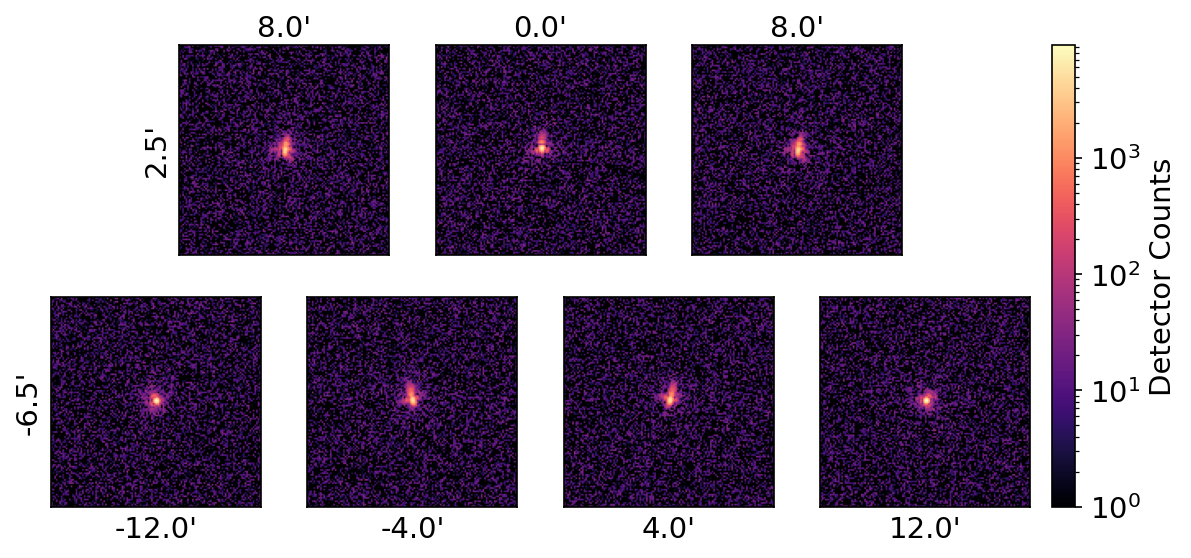

In [5]:
pupil = sys.pupil
fields = [(sys.cfg['sources'][src]['position_x'], sys.cfg['sources'][src]['position_y']) for src in sys.cfg['sources']]

utils.plot_psfs_7(psfs=images, fields=fields)

## WFES

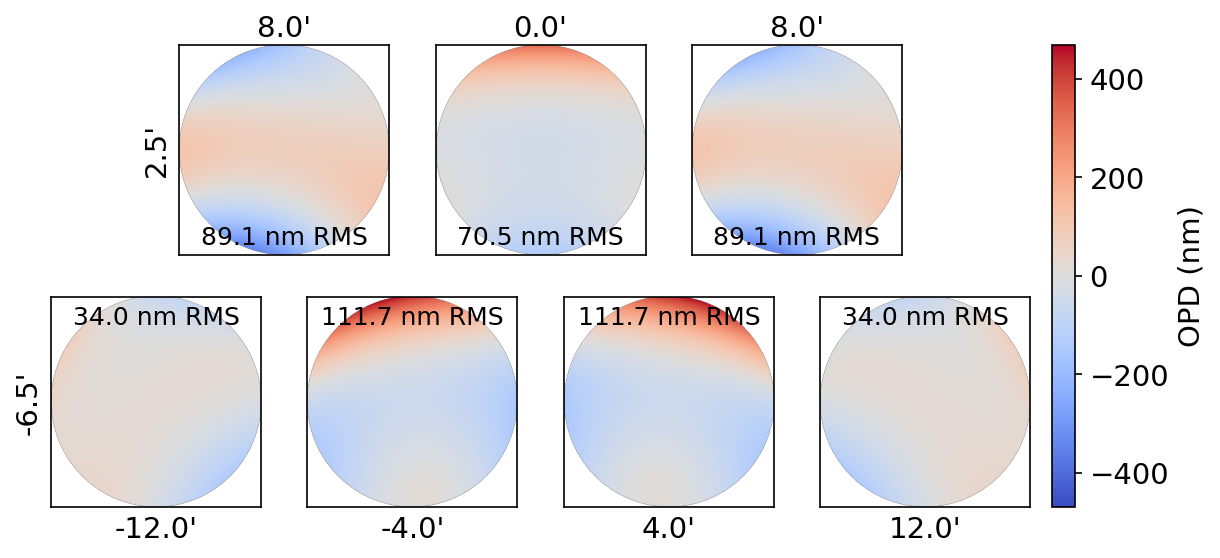

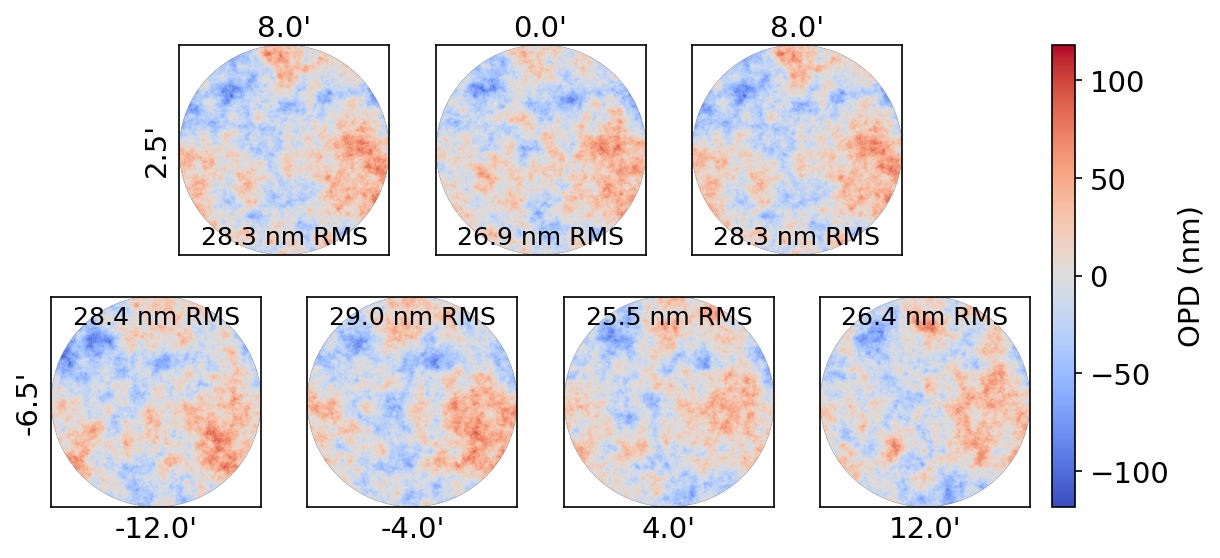

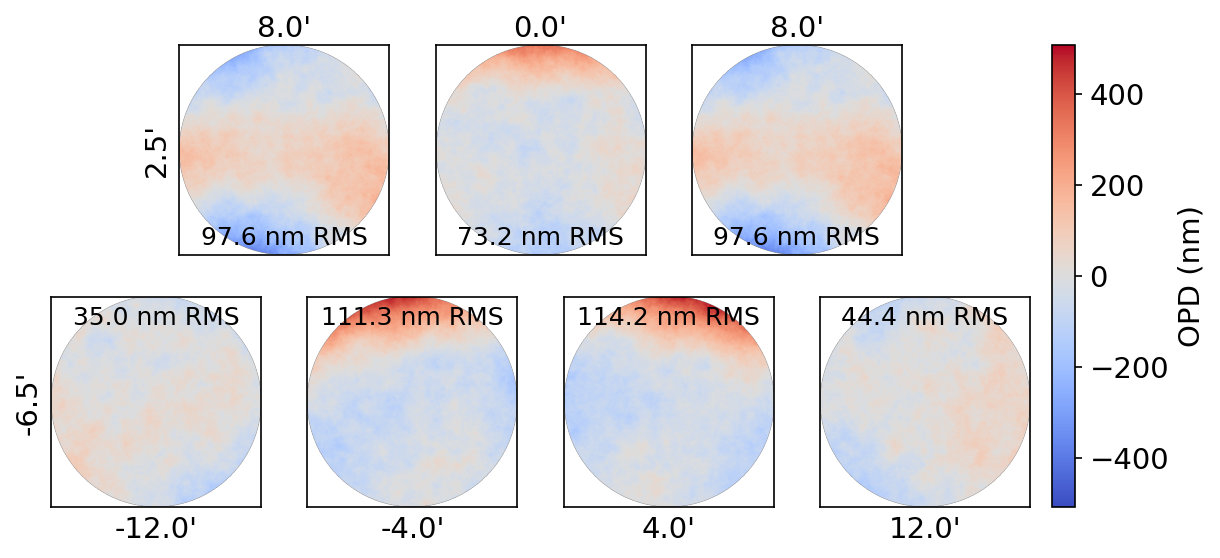

In [6]:
opds_fields = copy.deepcopy(sys.opds_field)
opds_optics = copy.deepcopy(sys.opds_optics)
opds_truths = [opd_field + opd_optics for (opd_field, opd_optics) in zip(opds_fields, opds_optics)]

opds_fields_nominal = opds_fields

utils.plot_opds_7(opds=opds_fields, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_optics, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_truths, pupil=pupil, fields=fields)

## FIELD DEPENDENT ABERRATIONS

In [9]:
raytrace = Lazuli_stop()

# zernike basis (excluding piston) up to Z37
x, y = make_xy_grid(sys.pupil.shape[0], dx=sys.dx_pup)
r, t = cart_to_polar(x, y)
nms = [noll_to_nm(i) for i in range(2, 37)]
zernikes = list(zernike_nm_seq(nms, r, t, norm=True))
zernikes = [z / np.max(np.abs(z)) for z in zernikes]

# indices for the zernikes which exhibit field dependence that changes with alignment: defocus, coma, astig, trefoil, spherical
# THESE DO NOT CORRESPOND TO NOLL INDICES
inds = [i + 2 for i in range(8)]

# field positions to evaluate
fields_x = np.linspace(-16.2, 16.2, 33) / 60 # +/- 16.2 arcmin in x
fields_y = np.linspace(-4.8, 4.8, 11) / 60  # +/- 4.8 arcmin in y

# initialize array to hold coeffs for field-dependent zernikes at nominal alignment
field_coeffs_nom = np.zeros((len(inds), len(fields_x), len(fields_y)))

# loop through fields
for i, field_x in enumerate(fields_x):
    for j, field_y in enumerate(fields_y):
        
        # get raytrace OPD at field point
        ray_data = raytrace.get_OPD(fieldX=field_x.get(), fieldY=field_y.get(), npx=sys.pupil.shape[0])
        opd = np.array(ray_data['wavefront'].array.data * ~ray_data['wavefront'].array.mask) * sys.wvl0 * 1e3
        opd[~sys.pupil] = np.nan

        # decompose
        field_coeffs_nom[:, i, j] = lstsq(np.array(zernikes), opd)[inds]

# create interpolators for field-dependent zernikes
field_interps_nom = [interpolate.RegularGridInterpolator((fields_x, fields_y), field_coeffs_nom[i, :, :], method='cubic') for i in range(field_coeffs_nom.shape[0])]

# show field dependence for field-dependent zernikes
plt.figure(figsize=(15, 12))
for i in range(field_coeffs_nom.shape[0]):
    plt.subplot(4, 2, i + 1)
    plt.title(f'Z{i + 4:.0f}')
    plt.imshow(field_coeffs_nom[i, :, :].get().T, interpolation='bicubic', extent=[-16.2, 16.2, -4.8, 4.8])
    plt.xlabel('Arcmin')
    plt.colorbar(fraction=0.016, pad=0.04, label='nm')

AttributeError: 'telescope' object has no attribute 'dx_pup'

## MISALIGN

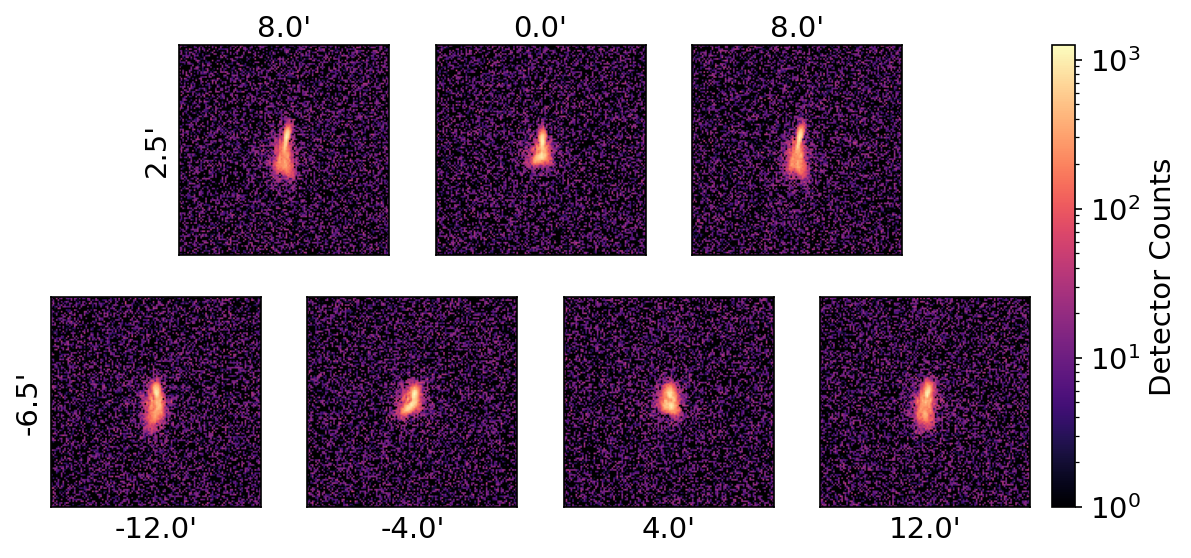

In [8]:
misalignments = utils.load_pickle('/home/derbyk/src/ffpr/data/misalignment_cases_100_dec_50um_tilt_5as_wM1.pkl')
m = misalignments[0]

sys.move_optics(M1_motion=m['M1'], M2_motion=m['M4'], M3_motion=m['M4'], M4_motion=m['M4'])

dark = sys.get_dark(stacked_frames=1)
images = [im - dark for im in sys.snap(stacked_frames=1)]

utils.plot_psfs_7(psfs=images, fields=fields)

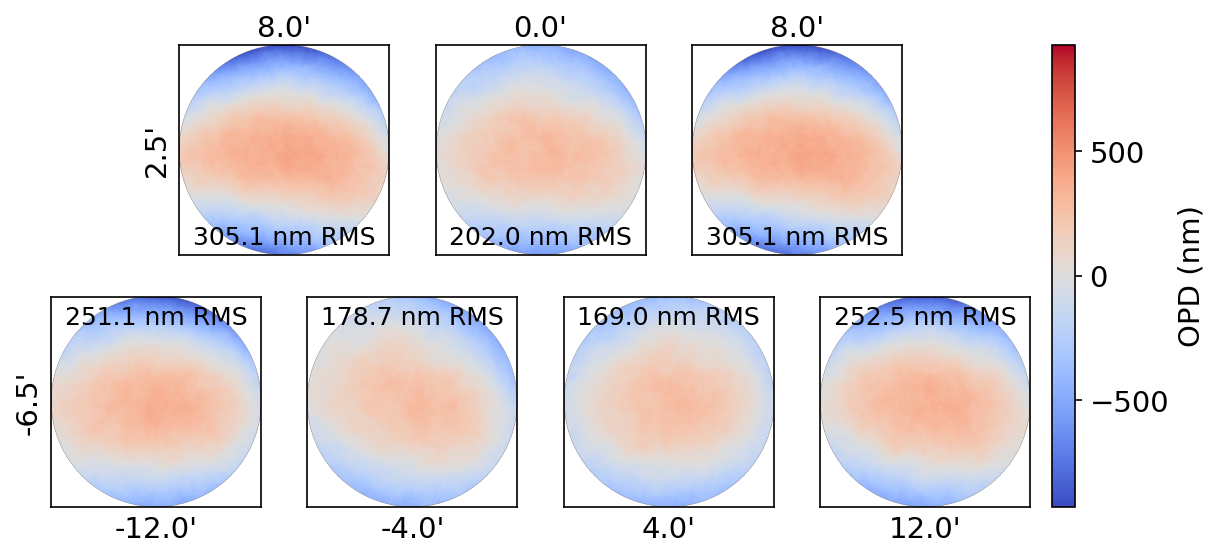

In [9]:
opds_fields = copy.deepcopy(sys.opds_field)
opds_optics = copy.deepcopy(sys.opds_optics)
opds_truths = [opd_field + opd_optics for (opd_field, opd_optics) in zip(opds_fields, opds_optics)]

utils.plot_opds_7(opds=opds_truths, pupil=pupil, fields=fields)

In [10]:
# create zernike basis 
x, y = make_xy_grid(shape=512, diameter=2)
r_norm, t = cart_to_polar(x, y)
nms = [noll_to_nm(i) for i in range(2, 12)]
zernikes = list(zernike_nm_seq(nms, r_norm, t, norm=True))

# for some reason, how the basis is normalized REALLY matters
# having everything normalized to unit peak-to-valley works best
zernikes = [z - np.min(z) for z in zernikes]
zernikes = [z / np.max(np.abs(z[sys.pupil])) for z in zernikes]

ind = 1
opd_check = opds_fields[ind] - opds_fields_nominal[ind]
coeffs_check = lstsq(np.array(zernikes), opd_check)
coeffs_check 

array([ -46.55027691, -200.84719736, -411.35064545,  -93.08548497,
        451.79799552,   15.95374078, -155.94597198,   59.57764749,
       -158.42071601,  186.0005197 ])

In [56]:
opt.coeffs

array([ 187.26554419,  797.30722222, 3911.68978846, -362.96008764,
       1754.52113793, 1143.6601662 ,  105.4556537 , 1408.76913841,
       1805.66868611, 1700.02018088])

## FFPR

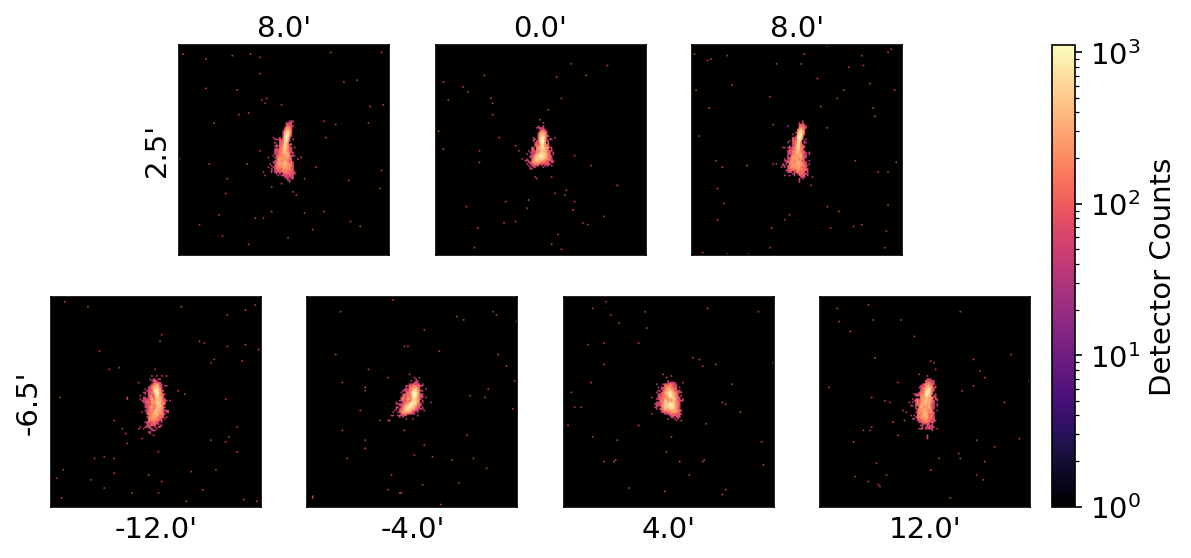

In [73]:
dark = sys.get_dark(stacked_frames=1)
images = [im - dark for im in sys.snap(stacked_frames=1)]

fields = [(sys.cfg['sources'][src]['position_x'], sys.cfg['sources'][src]['position_y']) for src in sys.cfg['sources']]

snr_thresh = 5
noise_lvl = dark.std()

filtered_images = []

masks = []

for im in images:
    mask = im > noise_lvl * snr_thresh
    masks.append(mask)
    filtered_images.append(im * mask)

utils.plot_psfs_7(psfs=filtered_images, fields=fields)

In [74]:
# bing bong
max_kicks = 5
iters_bing_bong = 20
iters_psf = 20
max_ls = 20
thresh_minima = 1e-1
frac_conv = 5e-2

bounds = [(1000., 1000.) for _ in range(9)]

rng = np.random.default_rng(seed=727)

# refresh bing bong things
count = 1
bing = 1.
bong = 1.
kicks = 0
pre_kick_f = 1.
pre_kick_x = 0

efl = sys.cfg['general']['f_eff']
pupil_dx = sys.cfg['optics']['m1']['diam'] / sys.cfg['general']['npix_pupil']
focal_dx = sys.cfg['detector']['dx_focal']

opt = FFPR2(wvls=sys.wvls.tolist(), amp=sys.pupil, max_zernike=11, fields=fields, divs=opds_fields_nominal, efl=efl, 
            psfs=filtered_images, pupil_dx=pupil_dx, focal_dx=focal_dx, error=gain_invariant_error, masks=masks, jitter_kernel=sys.jitter_kernel)

# BING BONG
print('BEGIN BING BONG')

while True: 
    print('---------------')

    fg = partial(opt.fg, opt_param='common', opt_weights=None)
    x0 = copy.deepcopy(opt.coeffs.get())
    minimize(fg, x0=x0, jac=True, method='L-BFGS-B',
            options={'maxls' : max_ls, 'ftol' : 1e-20, 'gtol' : 1e-10, 'disp' : 0, 'maxiter' : iters_bing_bong})

    bing = float(opt.costs[-1])
    print(f'BING {count:02.0f} | f = {bing:.2e}')

    if (np.abs(bong - bing) <= (frac_conv * bong)) and bing < thresh_minima:
        print(f'CONVERGED: BING WITHIN {frac_conv * 100:2.0f}% OF BONG, f BELOW {thresh_minima:.2e}')
        print('TERMINATING BING BONG')
        break
    
    fg = partial(opt.fg, opt_param='all', opt_weights=None)
    x0 = np.concatenate((copy.deepcopy(opt.field_terms), copy.deepcopy(opt.coeffs)), axis=0).get()
    minimize(fg, x0=x0, jac=True, method='L-BFGS-B', 
            options={'maxls' : max_ls, 'ftol' : 1e-20, 'gtol' : 1e-10, 'disp' : 0, 'maxiter' : iters_bing_bong})

    bong = float(opt.costs[-1])
    print(f'BONG {count:02.0f} | f = {bong:.2e}')

    if bong < thresh_minima:
        if (np.abs(bing - bong) <= (frac_conv * bing)):
            print(f'CONVERGED: BONG WITHIN {frac_conv * 100:2.0f}% OF BING, f BELOW {thresh_minima:.2e}')
            print('TERMINATING BING BONG')
            break

    if bong > thresh_minima:
        if (np.abs(bing - bong) <= (frac_conv * bing)):
            if bong > pre_kick_f:
                print('KICK UNSUCCESSFUL, UNKICKING')
                pre_kick_f = copy.deepcopy(bong)
                opt.coeffs = pre_kick_x
            else:
                if kicks == max_kicks:
                    print('NO MORE KICKING, YOU MAY BE COOKED')
                    print('TERMINATING BING BONG')
                    break
                else:
                    print('STUCK IN MINIMA, STILL ABOVE CONVERGENCE THRESHOLD, KICKING')
                    pre_kick_x = copy.deepcopy(opt.coeffs)
                    pre_kick_f = copy.deepcopy(bong)
                    # opt.coeffs[2::2] *= -0.5
                    # opt.coeffs[1::2] *= -0.5
                    opt.coeffs *= rng.uniform(low=-1, high=1, size=len(opt.coeffs))
                    opt.field_terms = np.zeros(len(opt.field_terms))
                    kicks += 1

    count += 1

print('---------------')
print('INDIVIDUAL PSF OPTIMIZATION')

for pdpr in opt.PDPR_list:
    fg = partial(pdpr.fg, opt_param='coeffs', opt_weights=None)
    x0 = pdpr.coeffs.get()

    minimize(fg, x0=x0, jac=True, method='L-BFGS-B', 
            options={'maxls' : max_ls, 'ftol' : 1e-20, 'gtol' : 1e-10, 'disp' : 0, 'maxiter' : iters_psf})

# for pdpr in opt.PDPR_list:
#     fg = partial(pdpr.fg, opt_param='map', opt_weights=None)
#     x0 = pdpr.map.ravel().get()

#     minimize(fg, x0=x0, jac=True, method='L-BFGS-B', 
#              options={'maxls' : max_ls, 'ftol' : 1e-20, 'gtol' : 1e-10, 'disp' : 0, 'maxiter' : iters_psf})

print('---------------')
print('BING BONG DONE')
print()

BEGIN BING BONG
---------------
BING 01 | f = 3.40e-01
BONG 01 | f = 3.28e-01
STUCK IN MINIMA, STILL ABOVE CONVERGENCE THRESHOLD, KICKING
---------------
BING 02 | f = 5.05e-01
BONG 02 | f = 5.01e-01
KICK UNSUCCESSFUL, UNKICKING
---------------
BING 03 | f = 3.41e-01
BONG 03 | f = 3.28e-01
STUCK IN MINIMA, STILL ABOVE CONVERGENCE THRESHOLD, KICKING
---------------
BING 04 | f = 4.32e-02
BONG 04 | f = 4.11e-02
CONVERGED: BONG WITHIN  5% OF BING, f BELOW 1.00e-01
TERMINATING BING BONG
---------------
INDIVIDUAL PSF OPTIMIZATION
---------------
BING BONG DONE



/tmp/ipykernel_611225/473777310.py:12: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim([0, 1])


(0.024945831556348278, 1)

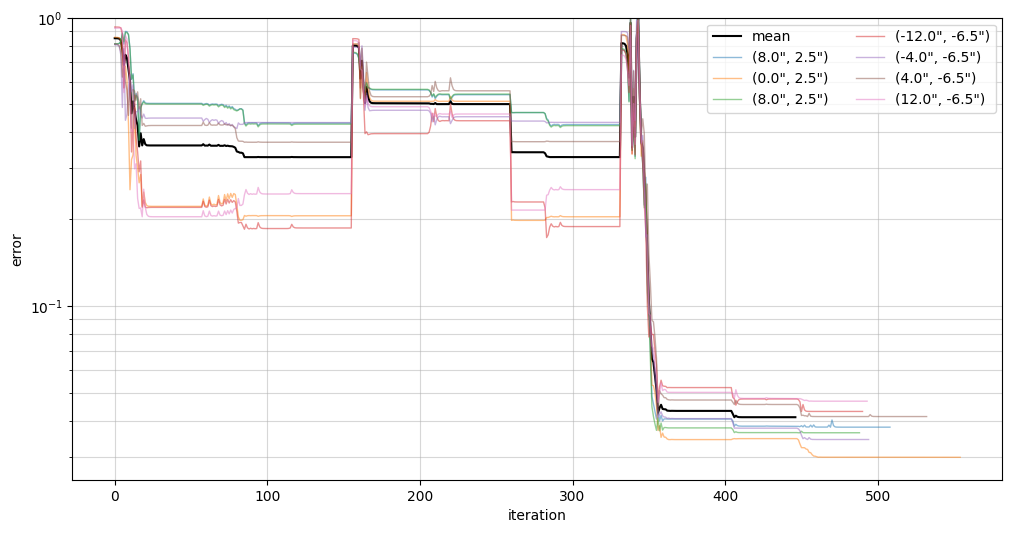

In [75]:
plt.figure(figsize=(12, 6))
plt.semilogy(np.array(opt.costs).get(), label='mean', color='k', linewidth=1.5)
plt.xlabel('iteration')
plt.ylabel('error')
plt.grid(which='both', alpha=0.5)

for pdpr, field in zip(opt.PDPR_list, fields):
    plt.semilogy(np.array(pdpr.costs).get(), label=f'({field[0]:.1f}", {field[1]:.1f}")', alpha=0.5, linewidth=1)

plt.legend(ncols=2)
# plt.xlim([0, len(opt.costs)])
plt.ylim([0, 1])

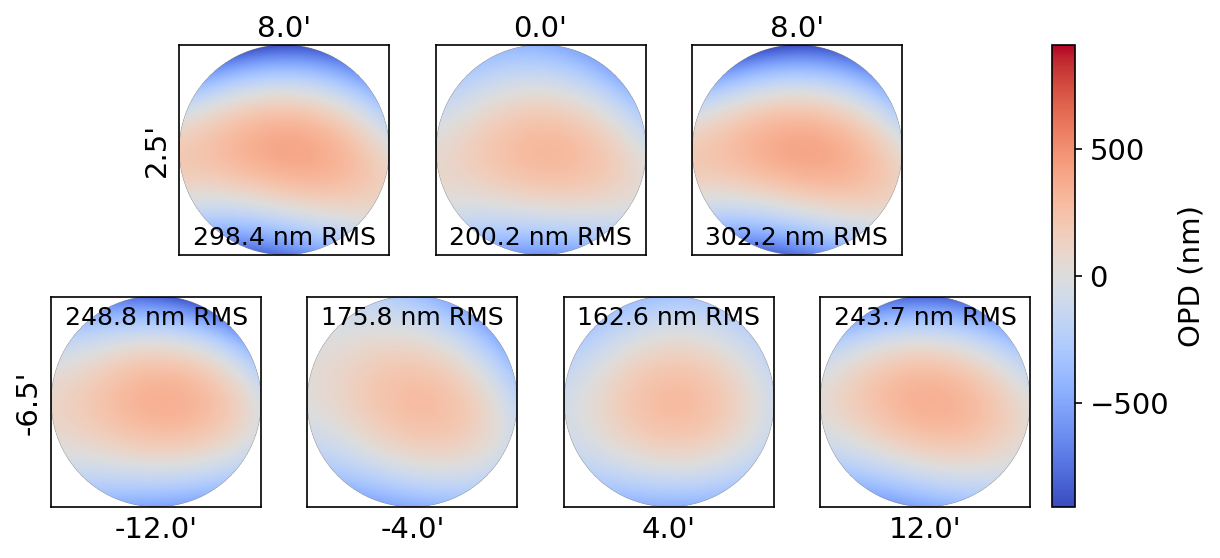

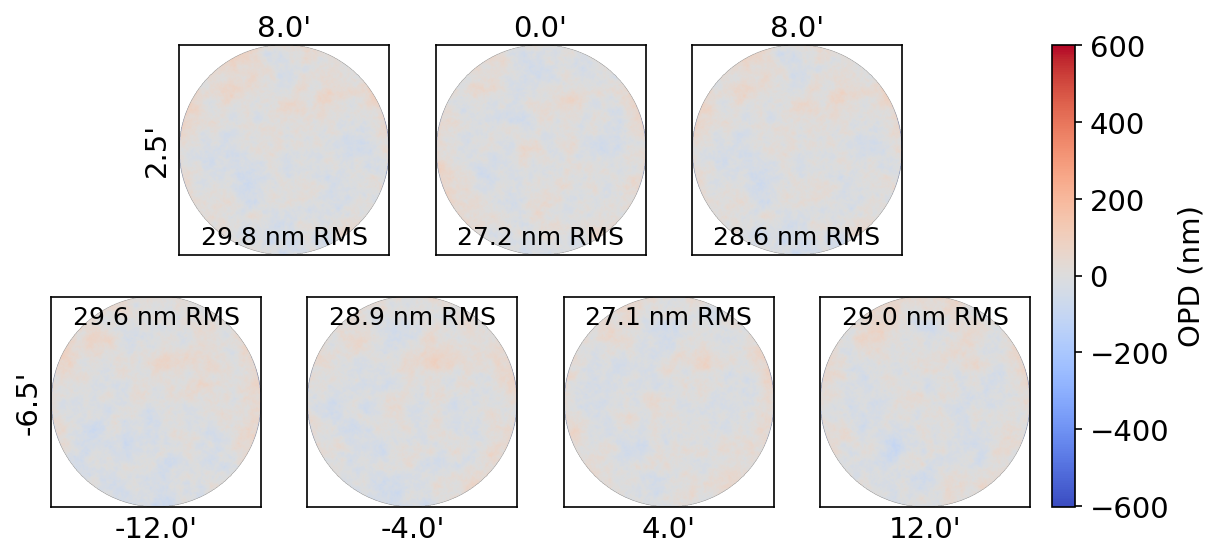

In [76]:
opds_estimates = [pdpr.models[0].opd + pdpr.models[0].div for pdpr in opt.PDPR_list]
opds_residuals = [estimate - truth for estimate, truth, optics in zip(opds_estimates, opds_truths, opds_optics)]

utils.plot_opds_7(opds=opds_estimates, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_residuals, pupil=pupil, fields=fields)

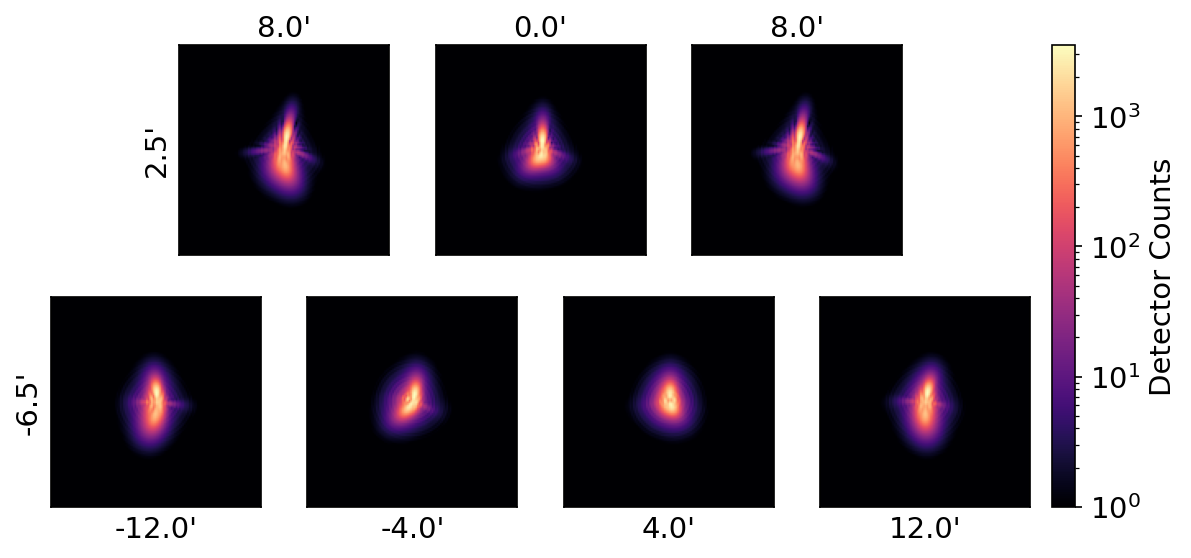

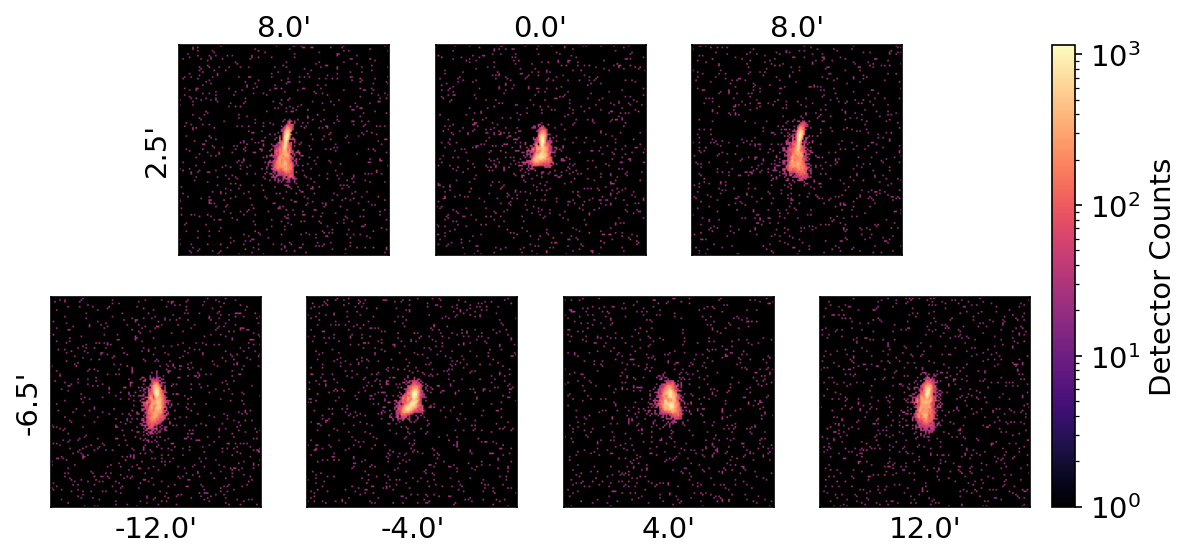

In [72]:
psf_estimates = [pdpr.models[0].I for pdpr in opt.PDPR_list]

psf_truths = [pdpr.models[0].psf for pdpr in opt.PDPR_list]

utils.plot_psfs_7(psfs=psf_estimates, fields=fields)

utils.plot_psfs_7(psfs=psf_truths, fields=fields)